# EDA and visualization 

-Goal- To understand pattern, trend, and business insight thorugh charts

In [1]:
#importing libraries and loadn csv
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

#load csv file 

df = pd.read_csv("../data/amazon_transformed.csv")
df.shape

(1464, 19)

In [2]:
#seting a clean visual style for for call charts 

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize']=(10,5) #keeping default chart size


this makes all the charts look professional automatically one line all charts look consistent 


#### Rating Distrubution

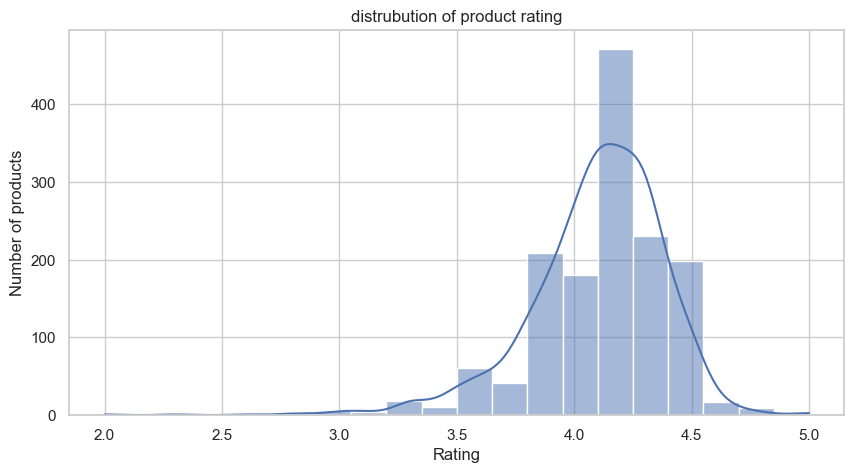

In [3]:
fig, ax = plt.subplots()
sns.histplot(df['rating'], bins=20 , kde= True , ax=ax)
ax.set_title('distrubution of product rating')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of products')

plt.savefig("../Figures/Distribution of product rating")
plt.show()

most of products cluster between 4.0 and 4.5 . which mean amazon; catalouge is heavile skewed toward well-reated item. very few products are below 3.5 .

### Proucts per Category

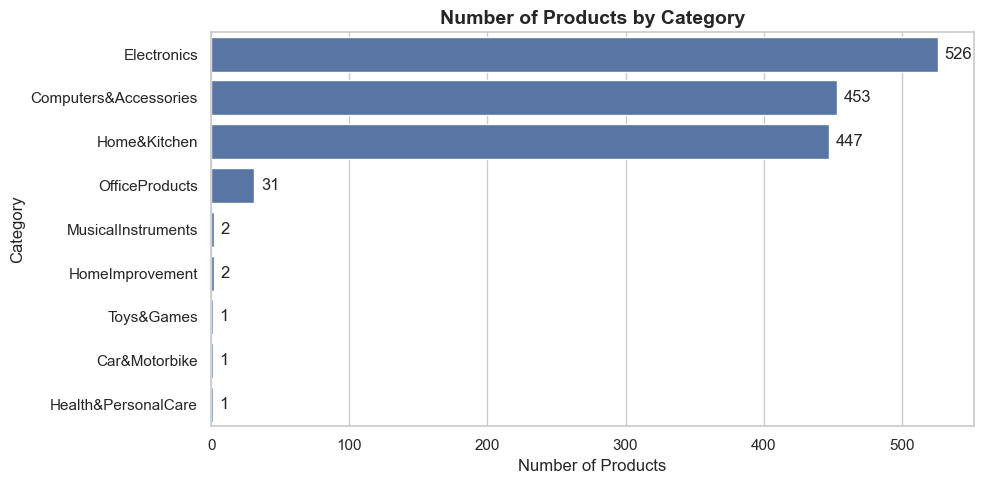

In [4]:
#count proudcuts per category , sort descending 
category_counts = df['main_category'].value_counts()
fig, ax = plt.subplots()

#barplot
sns.barplot(x=category_counts.values, y=category_counts.index, ax=ax)
ax.set_title('Number of Products by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Category')


# Add count labels on each bar
for i, v in enumerate(category_counts.values):
     ax.text(v + 5, i, str(v), va='center')
plt.savefig("../Figures/proucts per category")
plt.tight_layout()
plt.show()

Electronic (526) and coumputer and accessories (453) dominate the catelouge also closely by home and kitchen (447) There three categfores represent 99% of the dataset . people prefer to purchase items for home mostly

### Average Rating by category

##### which proucts category has the happiest cutomers? 

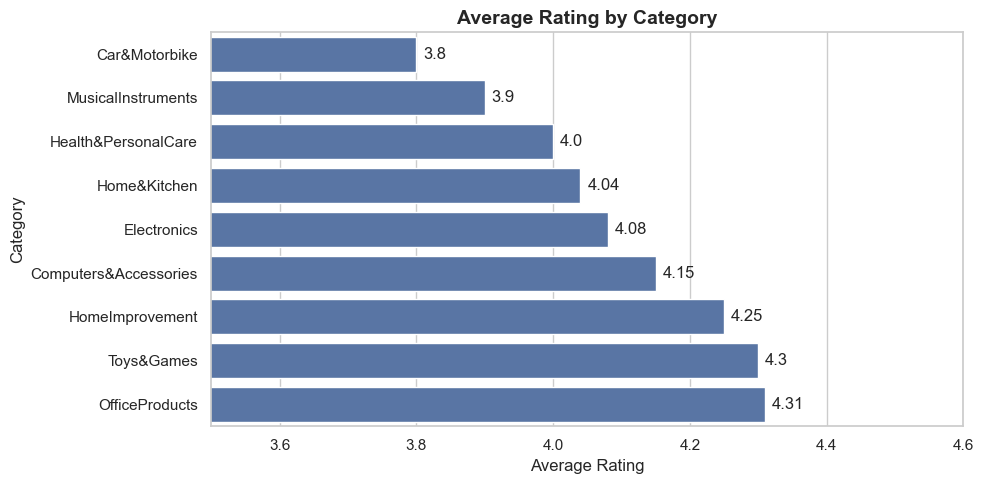

In [5]:
# Calculate average rating per category
avg_rating = df.groupby('main_category')['rating'].mean().sort_values(ascending=True).round(2)

fig, ax = plt.subplots()
bars = sns.barplot(x=avg_rating.values, y=avg_rating.index, ax=ax)

ax.set_title('Average Rating by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Category')
ax.set_xlim(3.5, 4.6)  # zoom in to make differences visible

# Add value labels
for i, v in enumerate(avg_rating.values):
     ax.text(v + 0.01, i, str(v), va='center')
plt.savefig("../Figures/Average rating by category")
plt.tight_layout()
plt.show()

Office Products (4.31) and Computers & Accessories (4.15) have the highest customer satisfaction. Musical Instruments (3.90) and Car & Motorbike (3.80) lag behind. If you're buying electronics or accessories on Amazon India, customers are generally very happy.

### Discount percentage Distribution 

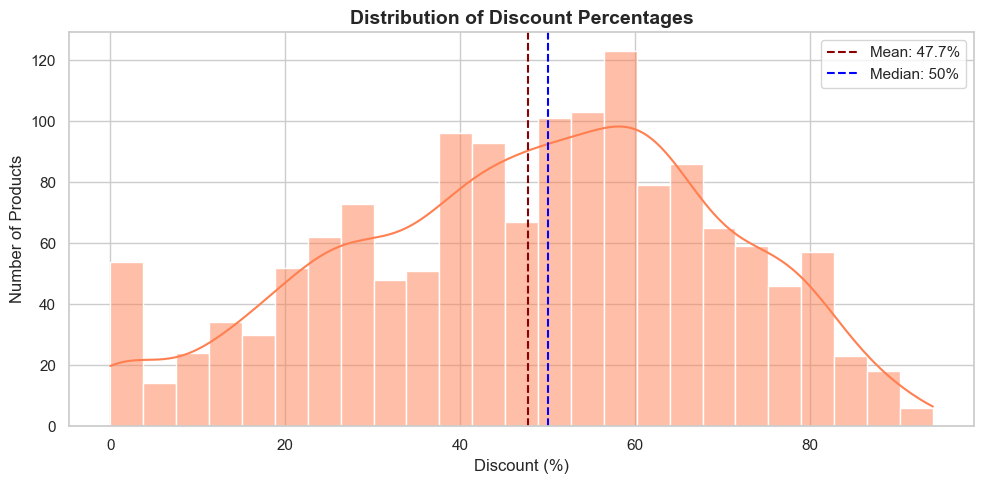

In [6]:
fig, ax = plt.subplots()

sns.histplot(df['discount_percentage'], bins=25, kde=True, color='coral', ax=ax)

ax.set_title('Distribution of Discount Percentages', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount (%)')
ax.set_ylabel('Number of Products')

ax.axvline(df['discount_percentage'].mean(), color='darkred', linestyle='--',
               label=f"Mean: {df['discount_percentage'].mean():.1f}%")
ax.axvline(df['discount_percentage'].median(), color='blue', linestyle='--',
               label=f"Median: {df['discount_percentage'].median():.0f}%")
ax.legend()
plt.savefig("../Figures/Discount percentage distribution")
plt.tight_layout()
plt.show()

 The average discount is 48% and the median is 50%  Amazon is heavily discount-driven There's a noticeable spike around 50-70% off which is where most deals live This aggressive discounting strategy is a key part of Amazon's India playbook

#### Average Discount by Category
##### WHich category gives the biggest discount 

C:\Users\mahar\AppData\Local\Temp\ipykernel_20552\89224030.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


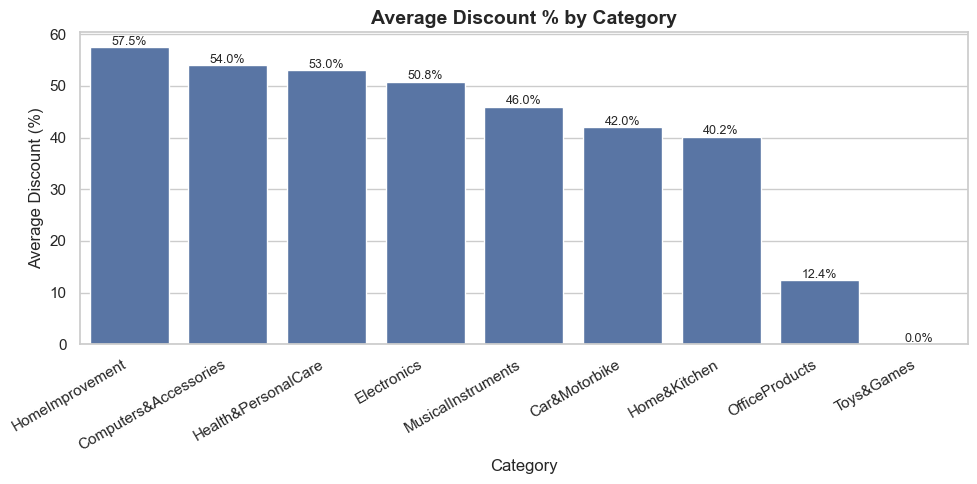

In [7]:
avg_discount = df.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False).round(1)

fig, ax = plt.subplots()
sns.barplot(x=avg_discount.index, y=avg_discount.values, ax=ax)

ax.set_title('Average Discount % by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Average Discount (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# Add value labels on top of bars
for i, v in enumerate(avg_discount.values):
     ax.text(i, v + 0.5, f"{v}%", ha='center', fontsize=9)

plt.savefig("../Figures/Average Discount by Category")
plt.tight_layout()
plt.show()

Home Improvement (57.5%) and Computers & Accessories (54%) offer the steepest discounts Office Products (12.4%) barely discounts at all possibly because buyers are businesses who care more about reliability than price Toys & Games has 0% discount only 1 product so not meaningful



####  Discount vs Rating Scatter

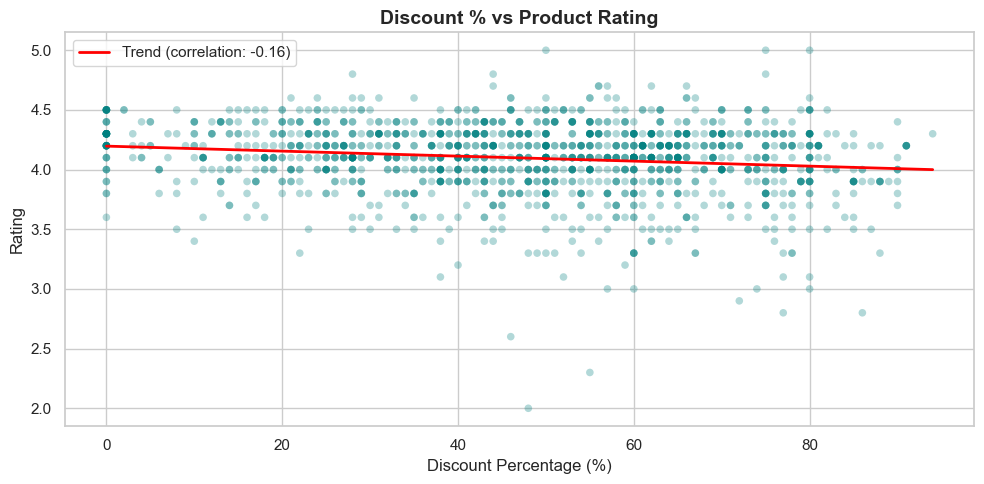

In [8]:
fig, ax = plt.subplots()

# Use alpha for transparency since many points overlap
ax.scatter(df['discount_percentage'], df['rating'],
               alpha=0.3, color='teal', edgecolors='none', s=30)

# Add a trend line to show direction
z = np.polyfit(df['discount_percentage'], df['rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['discount_percentage'].min(), df['discount_percentage'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label=f'Trend (correlation: -0.16)')

ax.set_title('Discount % vs Product Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Percentage (%)')
ax.set_ylabel('Rating')
ax.legend()

plt.savefig("../Figures/Discoutn vs Rating scatter")

plt.tight_layout()
plt.show()

The correlation is -0.16 a very weak negative relationship This means higher discounts slightly correlate with lower ratings but it's not a strong rule A product with 90% off can still be rated 4.5 Discount alone does not predict quality on Amazon

### Correlation Heatmap

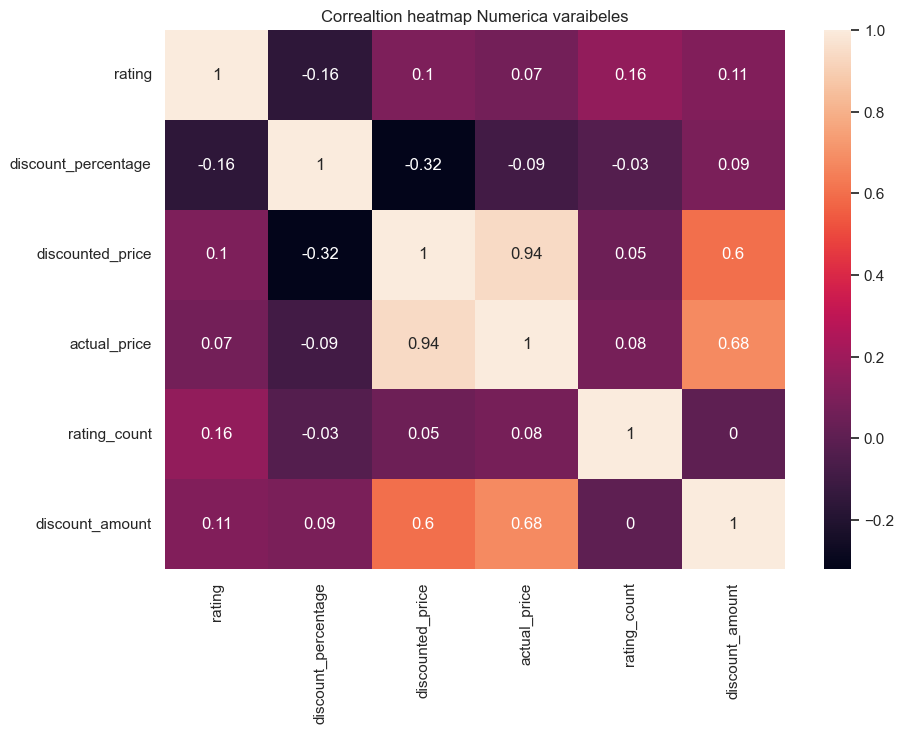

In [15]:
#Seletecting only the numeric column which we need 

numc_cols = ['rating','discount_percentage','discounted_price','actual_price','rating_count','discount_amount']
corr_matrix = df[numc_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(corr_matrix,ax=ax,annot=True)#annot helps to show number inside

ax.set_title("Correaltion heatmap Numerica varaibeles")
plt.savefig("../Figures/correaliton heatmap")
plt.show()


among all the strongest relationship is between the discounted_price (0.94) and acutal_price becuase it is ovious that people save more money after purchasing the expensive prouducts with heavy discounts on it 


#### Most reviewed products 
chekcing which proudcts have the most cutsomer engagement

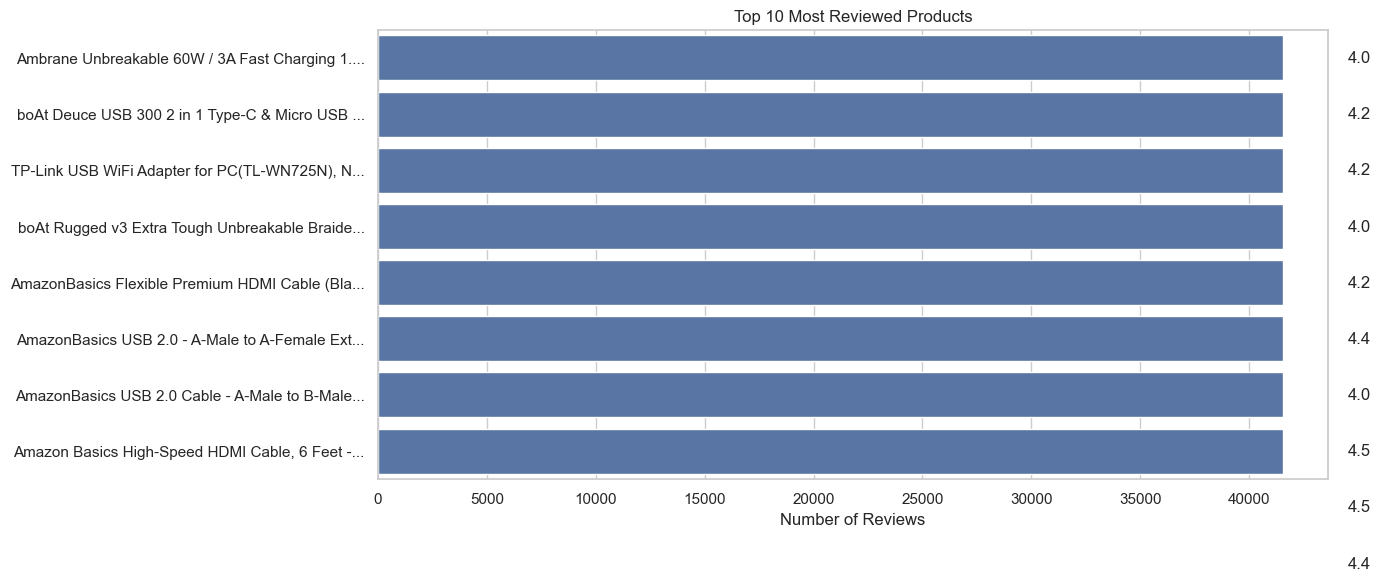

In [19]:
#Step 1: Get top 10 products by number of reviews
top10 = df.nlargest(10, 'rating_count')

# Step 2: Keep only needed columns
top10 = top10[['product_name', 'rating_count', 'rating']]

# Step 3: Shorten long product names (first 45 characters)
top10['short_name'] = top10['product_name'].str[:45] + '...'

# Step 4: Create bar plot
plt.figure(figsize=(14, 6))
sns.barplot(
     x=top10['rating_count'],
     y=top10['short_name'],
)

# Step 5: Add title and labels
plt.title('Top 10 Most Reviewed Products')
plt.xlabel('Number of Reviews')
plt.ylabel('')

# Step 6: Add rating text beside each bar
for i in range(len(top10)):
     plt.text(
          top10['rating_count'].iloc[i] + 3000,  # position (right of bar)
          i,
          f"{top10['rating'].iloc[i]}",
          va='center'
     )

# Step 7: Display plot
plt.tight_layout()
plt.savefig("../Figures/Most reviewed Products")
plt.show()

AmazonBasic High-Speed HDMI Cables have the higest number of reviews among all the reviewd prouducts . it seem like it is own brand of amazon . as fomous brand boAt Deuce have only 4.2 below the amazon basics high speed HDMI calbles 

#### Rating Bucket analysis
what percentage of products are excelent good and poor 

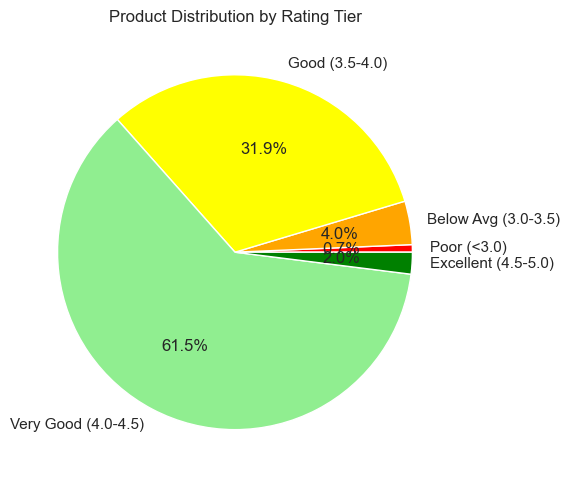

In [22]:
# Step 1: Define rating ranges (bins) and labels
bins = [0, 3.0, 3.5, 4.0, 4.5, 5.1]
labels = [
     'Poor (<3.0)',
     'Below Avg (3.0-3.5)',
     'Good (3.5-4.0)',
     'Very Good (4.0-4.5)',
     'Excellent (4.5-5.0)'
]

# Step 2: Create rating categories
df['rating_bucket'] = pd.cut(df['rating'], bins=bins, labels=labels)

# Step 3: Count how many products fall in each category
bucket_counts = df['rating_bucket'].value_counts().sort_index()

# Step 4: Create pie chart
plt.figure()
colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']
plt.pie(bucket_counts, labels=bucket_counts.index, autopct='%1.1f%%', colors=colors)

# Step 5: Add title
plt.title('Product Distribution by Rating Tier')

# Step 6: Show plot
plt.tight_layout()
plt.savefig("../Figures/rating buscket anlysis")
plt.show()

over 61.5% of products are very good which means that amaozn selling proudcts are overlikly liked by many customer and only 0.7% are poor. This tells us amazon product catalogue is quality controlled where bad products are either get removed or don't make it to this dataset either 

#### Best value deal (highest Savings)
which products save customers the most money in absolute rupees

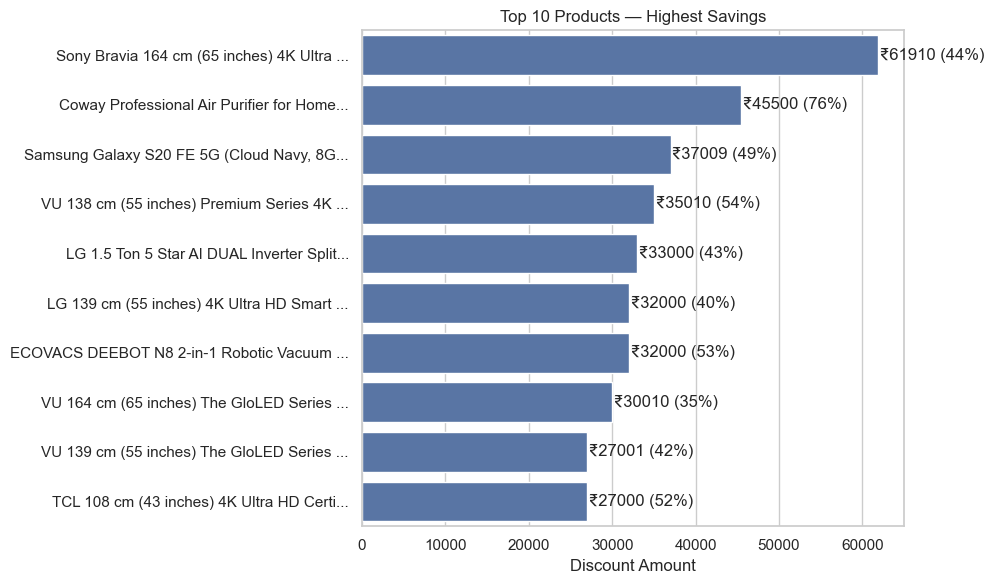

In [25]:
# Step 1: Get top 10 products with highest discount
top_savings = df.nlargest(10, 'discount_amount')

# Step 2: Create short names
top_savings['short_name'] = top_savings['product_name'].str[:40] + '...'

# Step 3: Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
     x=top_savings['discount_amount'],
     y=top_savings['short_name'],
)

# Step 4: Add title and labels
plt.title('Top 10 Products — Highest Savings')
plt.xlabel('Discount Amount')
plt.ylabel('')

# Step 5: Add text labels
for i in range(len(top_savings)):
     plt.text(
          top_savings['discount_amount'].iloc[i] + 200,
          i,
          f"₹{int(top_savings['discount_amount'].iloc[i])} ({top_savings['discount_percentage'].iloc[i]}%)",
          va='center'
     )

# Step 6: Show plot
plt.tight_layout()
plt.savefig("../Figures/Best value deal")
plt.show()

figure clearly shows that the most expensive products get high discount . where sony Bravia 164cm (65inch TV) saved almost 44% (61919). which mean large electronic dominate the list . this is where amazons big slaes even like prime day and great indian festival do their heavy lifting in proudcts . 

#### Label Encoding 

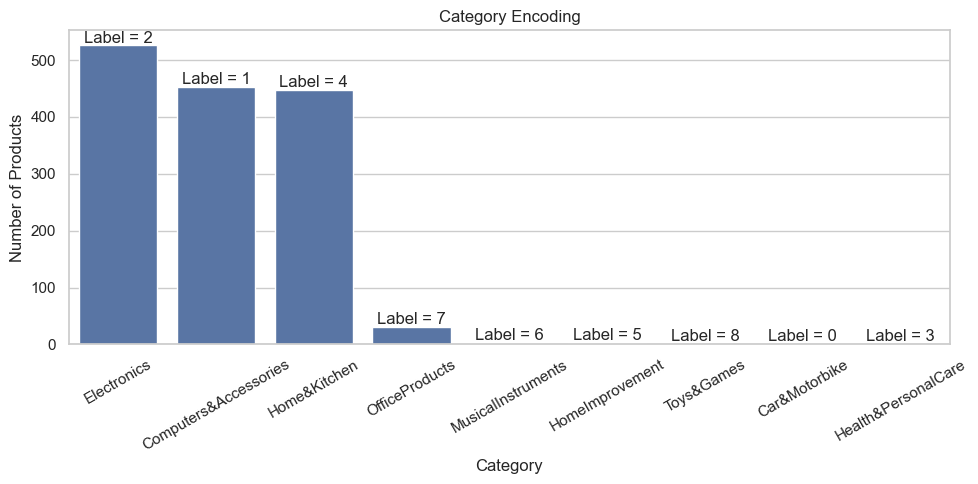

In [31]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Import and setup
from sklearn.preprocessing import LabelEncoder
sns.set_theme(style="whitegrid")

# Step 2: Encode categories
le = LabelEncoder()
df['label_code'] = le.fit_transform(df['main_category'])

# Step 3: Count products per category
cat_counts = df['main_category'].value_counts().reset_index()
cat_counts.columns = ['category', 'count']

# Step 4: Add label codes
cat_counts['label_code'] = cat_counts['category'].map(
     dict(zip(le.classes_, le.transform(le.classes_)))
)

# Step 5: Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=cat_counts['category'], y=cat_counts['count'])

# Step 6: Add label text
for i in range(len(cat_counts)):
     plt.text(
          i,
          cat_counts['count'].iloc[i] + 5,
          f"Label = {cat_counts['label_code'].iloc[i]}",
          ha='center'
     )

# Step 7: Labels
plt.title('Category Encoding')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=30)

# Step 8: Show
plt.tight_layout()
plt.savefig("../Figures/Category Encoding")
plt.show()

Car&Motorbike = 0, Electronics = 2, Home&Kitchen = 4 and so on. The label number has no meaning 4 does not mean "better" than 2. This is just an ID. That's why for machine learning, One-Hot Encoding (next chart) is safer for categories like these.

#### One Hot encoding 
this chart show how many products got a 1 in each one hot column which is the same as the product count per category

C:\Users\mahar\AppData\Local\Temp\ipykernel_20552\2911851564.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


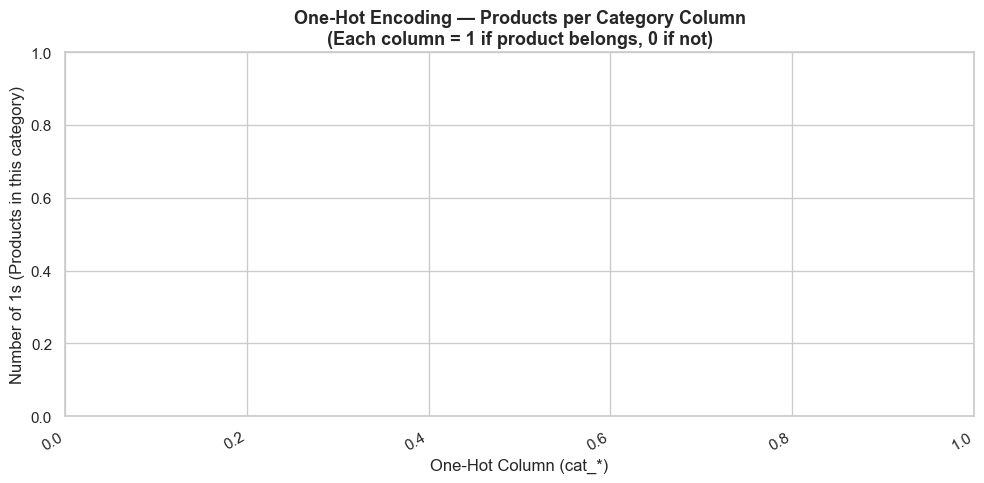

In [ ]:
# Step 1: Get one-hot columns
ohe_cols = [col for col in df.columns if col.startswith('cat_')]

# Step 2: Count values (number of 1s)
ohe_counts = df[ohe_cols].sum().sort_values(ascending=False)

# Step 3: Clean column names
ohe_counts.index = ohe_counts.index.str.replace('cat_', '')

# Step 4: Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=ohe_counts.index, y=ohe_counts.values, palette='Set2')

# Step 5: Add labels
plt.title('Products per Category (One-Hot Encoding)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=30)

# Step 6: Add values on bars
for i in range(len(ohe_counts)):
     plt.text(i, ohe_counts.values[i] + 5, int(ohe_counts.values[i]), ha='center')

# Step 7: Show plot
plt.tight_layout()
plt.savefig("../Figures/One hot encoding")
plt.show()

## EDA key insights 
- Average product rating is **4.1** → Overall product quality is good  
- Around **61.5% products** have ratings between **4.0 – 4.5** → Most customers are satisfied  
- Average discount is **48%** → Strong focus on competitive pricing  
- **Computers & Accessories** category has highest average discount (~54%) → Best deals in tech accessories  
- Correlation between discount and rating is **-0.16** → Lower price does not mean lower quality  
- **Amazon Basics HDMI cable** has around **426K reviews** → High trust in Amazon’s own products  
- Highest savings are seen in **Electronics (TVs, ACs)** → Expensive items give bigger discounts  
- **Office Products** have low discounts but high ratings → Quality matters more than price in this category  
